In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Constants
e_charge = 1.602176634e-19  # C
proton_mass = 1.67262192369e-27  # kg
c = 3.0e8  # m/s

B0 = np.array([0.0, 0.0, 0.15])  # Tesla, uniform field along +z

In [3]:
# --------------------------------------------------
# 1. Boris pusher for pure magnetic field
# --------------------------------------------------
def boris_push(r0, v0, q, m, B_vec, dt, n_steps):
    """
    Advance a single charged particle in a uniform B field using the Boris algorithm
    (no electric field).

    Parameters
    ----------
    r0 : array-like, (3,)
        Initial position [m].
    v0 : array-like, (3,)
        Initial velocity [m/s].
    q : float
        Charge [C].
    m : float
        Mass [kg].
    B_vec : array-like, (3,)
        Magnetic field [T].
    dt : float
        Time step [s].
    n_steps : int
        Number of steps.

    Returns
    -------
    t : ndarray, (n_steps+1,)
        Times.
    r : ndarray, (n_steps+1, 3)
        Positions.
    v : ndarray, (n_steps+1, 3)
        Velocities.
    """
    r = np.zeros((n_steps + 1, 3))
    v = np.zeros((n_steps + 1, 3))
    t = np.linspace(0, n_steps * dt, n_steps + 1)

    r[0] = np.array(r0, dtype=float)
    v[0] = np.array(v0, dtype=float)

    B = np.array(B_vec, dtype=float)
    qmdt2 = (q / m) * dt / 2.0

    # Boris method (E = 0)
    t_vec = qmdt2 * B        # "t" vector (not time!)
    t_mag2 = np.dot(t_vec, t_vec)
    s_vec = 2.0 * t_vec / (1.0 + t_mag2)

    for n in range(n_steps):
        # v_minus = v^n  (no electric field)
        v_minus = v[n]

        # v' = v_minus + v_minus x t
        v_prime = v_minus + np.cross(v_minus, t_vec)

        # v_plus = v_minus + v_prime x s
        v_plus = v_minus + np.cross(v_prime, s_vec)

        # v^{n+1} = v_plus (still no E field)
        v[n + 1] = v_plus

        # r^{n+1} = r^n + v^{n+1} dt
        r[n + 1] = r[n] + v[n + 1] * dt

    return t, r, v


In [4]:
# --------------------------------------------------
# 2. Helper: build initial velocity from speed + pitch angle
# --------------------------------------------------
def velocity_from_speed_and_pitch(v_mag, pitch_angle_deg, B_vec):
    """
    Construct an initial velocity vector with given speed and pitch angle
    relative to the magnetic field direction.

    pitch_angle = angle between v and B.
    """
    B = np.array(B_vec, dtype=float)
    B_hat = B / np.linalg.norm(B)

    theta = np.deg2rad(pitch_angle_deg)

    v_par_mag = v_mag * np.cos(theta)
    v_perp_mag = v_mag * np.sin(theta)

    # Choose a perpendicular direction to B_hat (arbitrary but fixed)
    # If B is along z, we can simply take x as perpendicular.
    # More generally:
    if np.allclose(B_hat, [0, 0, 1]) or np.allclose(B_hat, [0, 0, -1]):
        e1 = np.array([1.0, 0.0, 0.0])
    else:
        # take e1 not parallel to B_hat
        e1 = np.array([0.0, 0.0, 1.0])
        if np.isclose(np.abs(np.dot(e1, B_hat)), 1.0):
            e1 = np.array([0.0, 1.0, 0.0])

    # Build a perpendicular unit vector
    v_perp_dir = np.cross(B_hat, e1)
    v_perp_dir /= np.linalg.norm(v_perp_dir)

    v_par = v_par_mag * B_hat
    v_perp = v_perp_mag * v_perp_dir

    return v_par + v_perp



In [ ]:
# --------------------------------------------------
# 3. Demo: proton track with Boris pusher
# --------------------------------------------------
# Pick a moderately relativistic speed (we'll refine later)
v_mag = 0.6 * c
pitch_angle = 60.0  # degrees

v0 = velocity_from_speed_and_pitch(v_mag, pitch_angle, B0)
r0 = np.array([0.0, 0.0, 0.0])

q_p = +e_charge
m_p = proton_mass

# Gyrofrequency & period for reference
omega_c = np.abs(q_p) * np.linalg.norm(B0) / m_p
T_c = 2 * np.pi / omega_c
print("Cyclotron period (s):", T_c)

n_periods = 3.0
n_steps_per_period = 200  # time-step resolution
dt = T_c / n_steps_per_period
n_steps = int(n_periods * n_steps_per_period)

t, r, v = boris_push(r0, v0, q_p, m_p, B0, dt, n_steps)

x, y, z = r[:, 0], r[:, 1], r[:, 2]

Cyclotron period (s): 4.3729649912393144e-07


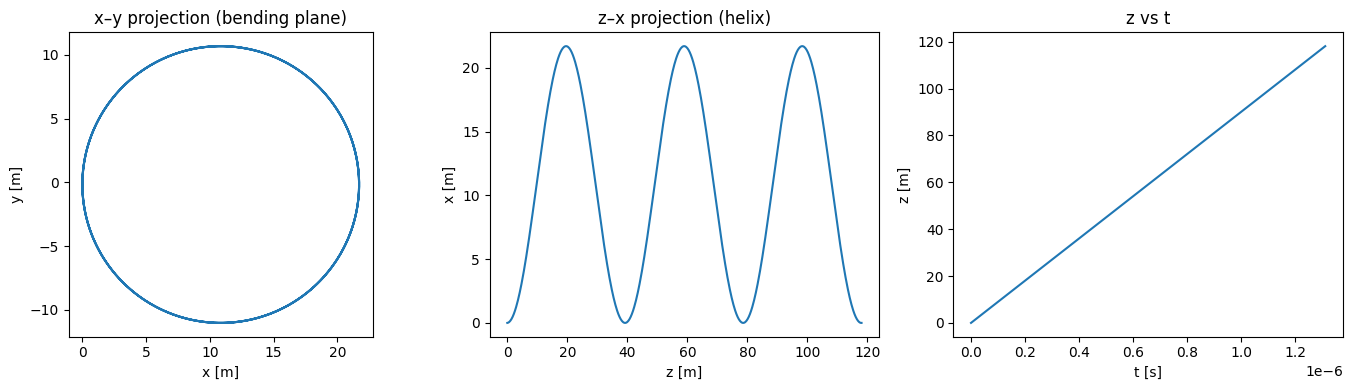

In [9]:
# --------------------------------------------------
# 4. Plot projections
# --------------------------------------------------
fig = plt.figure(figsize=(14, 4))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(x, y)
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
ax1.set_aspect("equal", "box")
ax1.set_title("x–y projection (bending plane)")

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(z, x)
ax2.set_xlabel("z [m]")
ax2.set_ylabel("x [m]")
ax2.set_title("z–x projection (helix)")

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(t, z)
ax3.set_xlabel("t [s]")
ax3.set_ylabel("z [m]")
ax3.set_title("z vs t")

plt.tight_layout()
plt.show()

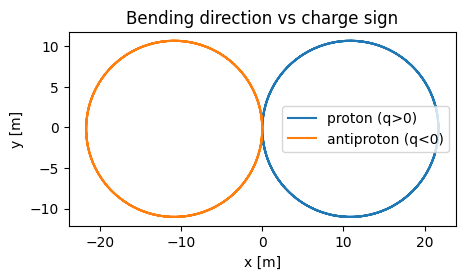

In [8]:
# Compare proton vs antiproton
q_anti_p = -q_p

t_p, r_p, _ = boris_push(r0, v0, q_p,  m_p, B0, dt, n_steps)
t_a, r_a, _ = boris_push(r0, v0, q_anti_p, m_p, B0, dt, n_steps)

plt.figure(figsize=(5, 5))
plt.plot(r_p[:, 0], r_p[:, 1], label="proton (q>0)")
plt.plot(r_a[:, 0], r_a[:, 1], label="antiproton (q<0)")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect("equal", "box")
plt.legend()
plt.title("Bending direction vs charge sign")
plt.show()
